In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

In [2]:
import geoflowkit as gfk
from geoflowkit.spatial import i_index

# Location Centrality: I-index

The I-index quantifies the **irreplaceability** of a location based on flows, combining flow volume and flow length into a single metric following the H-index principle.

**Definition**: The I-index of a location is the maximum value of *i* such that at least *i* flows with a length of at least α × *i* meters have reached this location.

Higher values indicate more irreplaceable locations that attract many flows with long distances.

In [3]:
# Load taxi flow data
flow_df = pd.read_csv('./data/sz_data/sz_taxi_flow.csv')
print(f'Flow data shape: {flow_df.shape}')
flow_df.head()

Flow data shape: (10000, 9)


,UID,stime,ox,oy,etime,dx,dy,distance,time_difference
0,32324,17:26:04,114.024651,22.527000,17:51:16,114.041283,22.553984,3.452617,1512
1,28591,15:30:09,114.101952,22.552500,16:28:07,113.809319,22.627451,31.177366,3478
2,28805,20:59:16,114.067680,22.523867,21:13:07,114.028687,22.526382,4.014803,831
3,22909,17:04:55,114.236618,22.713150,17:13:38,114.250298,22.721783,1.700085,523
4,35077,14:35:04,114.099564,22.549250,14:59:59,114.079002,22.545467,2.153116,1495


In [4]:
# Create FlowDataFrame from taxi flow data
fdf = gfk.read_csv(
    './data/sz_data/sz_taxi_flow.csv',
    use_cols=['ox', 'oy', 'dx', 'dy'],
    crs='EPSG:4326'
)
fdf = fdf.to_crs('EPSG:3857')
print(f'FlowDataFrame shape: {fdf.shape}')
fdf.head()

FlowDataFrame shape: (10000, 10)


,UID,stime,ox,oy,etime,dx,dy,distance,time_difference,geometry
0,32324,17:26:04,114.024651,22.527000,17:51:16,114.041283,22.553984,3.452617,1512,"FLOW (12693166.087200733 2574916.6312552323, 1..."
1,28591,15:30:09,114.101952,22.552500,16:28:07,113.809319,22.627451,31.177366,3478,"FLOW (12701771.195158543 2577990.044619046, 12..."
2,28805,20:59:16,114.067680,22.523867,21:13:07,114.028687,22.526382,4.014803,831,"FLOW (12697956.053570077 2574539.0623997897, 1..."
3,22909,17:04:55,114.236618,22.713150,17:13:38,114.250298,22.721783,1.700085,523,"FLOW (12716762.14570571 2597365.645660994, 127..."
4,35077,14:35:04,114.099564,22.549250,14:59:59,114.079002,22.545467,2.153116,1495,"FLOW (12701505.364214528 2577598.3035011766, 1..."


In [5]:
# Load zone (grid) data
zones = gpd.read_file('./data/sz_data/sz_border.gpkg')
zones = zones.to_crs('EPSG:3857')
# Add zone_id column if not present
if 'zone_id' not in zones.columns:
    zones['zone_id'] = range(len(zones))
print(f'Zones shape: {zones.shape}')
zones.head()

Zones shape: (10, 6)


,centroid_x,centroid_y,qh,Name,geometry,zone_id
0,114.143157,22.577605,罗湖,Luohu,"POLYGON ((12701560.611 2575797.495, 12701645.9...",0
1,114.041535,22.546180,福田,Futian,"POLYGON ((12688838.728 2573287.198, 12691038.0...",1
2,114.270206,22.596432,盐田,Yantian,"POLYGON ((12712461.825 2578499.419, 12712482.2...",2
3,113.851387,22.679120,宝安,Baoan,"MULTIPOLYGON (((12670196.544 2577298.51, 12670...",3
4,113.926290,22.766157,光明,Guangming,"POLYGON ((12690163.602 2603796.691, 12690092.9...",4


## I-index Calculation

We calculate the I-index using **destination points** (flows ending in each zone). The `od_type='d'` parameter specifies this.

We can also set a custom `alpha` value or let it be automatically calculated.

In [6]:
# Calculate I-index using destination points
result = i_index(fdf, zones, od_type='d')
print(f'I-index calculation complete')
print(f'Number of zones: {len(result)}')
print(f'Auto-calculated alpha: {result["alpha"].iloc[0]:.2f} meters')
result.head(10)

I-index calculation complete
Number of zones: 10
Auto-calculated alpha: 5.08 meters


,zone_id,I_index,flow_count,total_length,alpha,centroid_x,centroid_y,qh,Name,geometry
0,0,896,2090,11462.406661,5.079895,114.143157,22.577605,罗湖,Luohu,"POLYGON ((12701560.611 2575797.495, 12701645.9..."
1,1,1046,2886,16136.553150,5.079895,114.041535,22.546180,福田,Futian,"POLYGON ((12688838.728 2573287.198, 12691038.0..."
2,2,69,69,1021.037025,5.079895,114.270206,22.596432,盐田,Yantian,"POLYGON ((12712461.825 2578499.419, 12712482.2..."
3,3,684,1051,9434.486121,5.079895,113.851387,22.679120,宝安,Baoan,"MULTIPOLYGON (((12670196.544 2577298.51, 12670..."
4,4,15,15,222.416096,5.079895,113.926290,22.766157,光明,Guangming,"POLYGON ((12690163.602 2603796.691, 12690092.9..."
5,5,10,10,130.533193,5.079895,114.356936,22.691020,坪山,Pingshan,"POLYGON ((12737823.066 2591568.078, 12737819.9..."
6,6,603,926,5608.476480,5.079895,114.029687,22.686910,龙华,Longhua,"POLYGON ((12702471.943 2598636.96, 12702292.80..."
7,7,863,1599,11032.119177,5.079895,113.930714,22.544103,南山,Nanshan,"MULTIPOLYGON (((12669817.54 2559532.423, 12670..."
8,8,2,2,57.881924,5.079895,114.502205,22.571337,大鹏,Dapeng,"POLYGON ((12727646.106 2586863.558, 12727694.0..."
9,9,721,1341,7648.413920,5.079895,114.206790,22.695694,龙岗,Longgang,"POLYGON ((12697820.568 2583166.469, 12698044.5..."


In [7]:
# Summary statistics
print('I-index Statistics:')
print(result['I_index'].describe())
print(f'\nZones with I-index > 0: {(result["I_index"] > 0).sum()}')

I-index Statistics:
count      10.00000
mean      490.90000
std       420.08847
min         2.00000
25%        28.50000
50%       643.50000
75%       827.50000
max      1046.00000
Name: I_index, dtype: float64

Zones with I-index > 0: 10


## Visualization

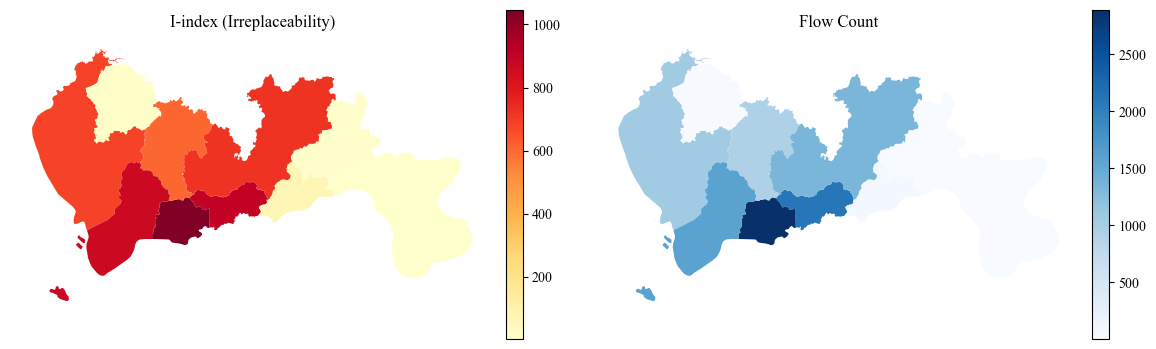

In [8]:
# Plot I-index on map
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: I-index values
result.plot(column='I_index', cmap='YlOrRd', legend=True, ax=axes[0],
            legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[0].set_title('I-index (Irreplaceability)')
axes[0].set_axis_off()

# Plot 2: Flow count
result.plot(column='flow_count', cmap='Blues', legend=True, ax=axes[1],
            legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[1].set_title('Flow Count')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

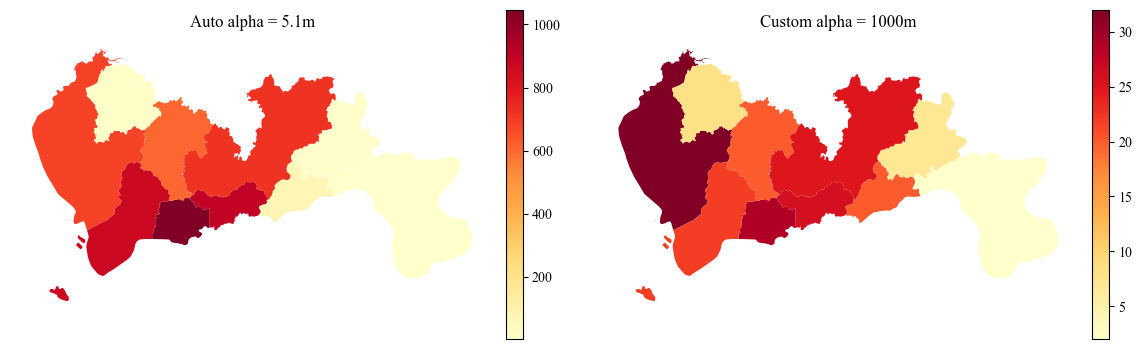

In [9]:
# Compare with custom alpha
result_1000 = i_index(fdf, zones, alpha=1000, od_type='d')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Auto alpha
result.plot(column='I_index', cmap='YlOrRd', legend=True, ax=axes[0],
            legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[0].set_title(f'Auto alpha = {result["alpha"].iloc[0]:.1f}m')
axes[0].set_axis_off()

# Custom alpha = 1000
result_1000.plot(column='I_index', cmap='YlOrRd', legend=True, ax=axes[1],
                 legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[1].set_title('Custom alpha = 1000m')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

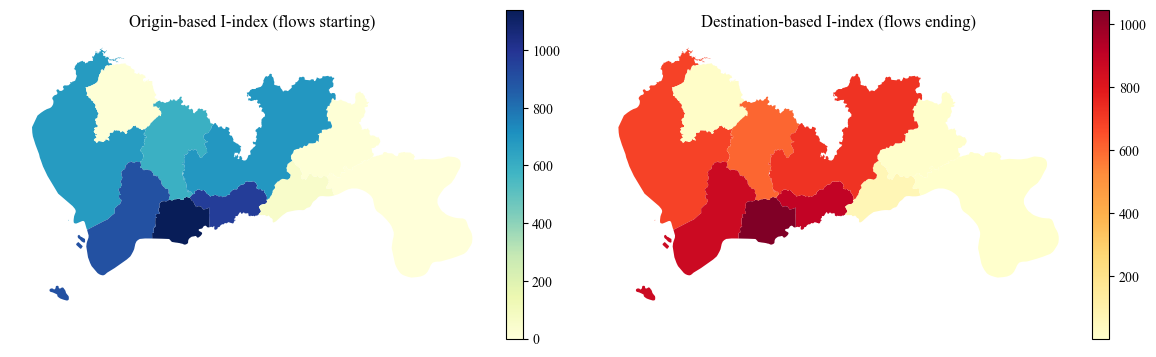

In [10]:
# Compare destination-based vs origin-based I-index
result_o = i_index(fdf, zones, od_type='o')
result_d = i_index(fdf, zones, od_type='d')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Origin-based
result_o.plot(column='I_index', cmap='YlGnBu', legend=True, ax=axes[0], 
              legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[0].set_title('Origin-based I-index (flows starting)')
axes[0].set_axis_off()

# Destination-based
result_d.plot(column='I_index', cmap='YlOrRd', legend=True, ax=axes[1],
              legend_kwds={'shrink': 0.7, 'aspect': 20, 'pad': 0.02})
axes[1].set_title('Destination-based I-index (flows ending)')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [11]:
# Find top irreplaceable locations
top_zones = result.nlargest(10, 'I_index')[['Name', 'I_index', 'flow_count', 'total_length', 'alpha']]
print('Top 10 Irreplaceable Locations:')
top_zones

Top 10 Irreplaceable Locations:


,Name,I_index,flow_count,total_length,alpha
1,Futian,1046,2886,16136.553150,5.079895
0,Luohu,896,2090,11462.406661,5.079895
7,Nanshan,863,1599,11032.119177,5.079895
9,Longgang,721,1341,7648.413920,5.079895
3,Baoan,684,1051,9434.486121,5.079895
6,Longhua,603,926,5608.476480,5.079895
2,Yantian,69,69,1021.037025,5.079895
4,Guangming,15,15,222.416096,5.079895
5,Pingshan,10,10,130.533193,5.079895
8,Dapeng,2,2,57.881924,5.079895


## Grid-based I-index Analysis

Instead of using administrative zones, we can create a regular grid over the study area to calculate I-index at a uniform spatial resolution.

In [12]:
# Create grid zones
from shapely.geometry import box

# Get bounding box and create grid
bounds = fdf.total_bounds
minx, miny, maxx, maxy = bounds

# Create 3km grid cells
grid_size = 3000  # meters

# Create grid polygons
grid_cells = []
for x in np.arange(minx, maxx, grid_size):
    for y in np.arange(miny, maxy, grid_size):
        cell = box(x, y, x + grid_size, y + grid_size)
        grid_cells.append(cell)

# Create grid GeoDataFrame
grid_zones = gpd.GeoDataFrame({
    'zone_id': range(len(grid_cells)),
    'geometry': grid_cells
}, crs=fdf.crs)

print(f'Grid created: {len(grid_zones)} cells ({grid_size/1000:.0f}km resolution)')
print(f'Grid bounds: minx={minx:.0f}, miny={miny:.0f}, maxx={maxx:.0f}, maxy={maxy:.0f}')

Grid created: 378 cells (3km resolution)
Grid bounds: minx=12665841, miny=2568085, maxx=12746585, maxy=2609722


In [13]:
# Filter grid cells that intersect with flow origins or destinations
# This removes empty grid cells outside the study area

# Get all origin and destination points
origins_geom = fdf.o.union_all()
destinations_geom = fdf.d.union_all()
all_points_geom = origins_geom.union(destinations_geom)

# Filter grid cells that intersect with any flow point
grid_zones['intersects'] = grid_zones.geometry.apply(
    lambda g: g.intersects(all_points_geom)
)
grid_zones_filtered = grid_zones[grid_zones['intersects']].copy()
grid_zones_filtered = grid_zones_filtered.drop(columns=['intersects'])
grid_zones_filtered = grid_zones_filtered.reset_index(drop=True)
grid_zones_filtered['zone_id'] = range(len(grid_zones_filtered))

print(f'Grid cells after filtering: {len(grid_zones_filtered)} / {len(grid_zones)}')
print(f'Filtered grid covers {len(grid_zones_filtered) * (grid_size/1000)**2:.1f} km²')

Grid cells after filtering: 195 / 378
Filtered grid covers 1755.0 km²


In [14]:
# Calculate I-index for filtered grid cells
result_grid = i_index(fdf, grid_zones_filtered, od_type='d')
print(f'Grid I-index calculated')
print(f'Auto alpha: {result_grid["alpha"].iloc[0]:.2f} meters')
print(f'\nGrid I-index Statistics:')
print(result_grid['I_index'].describe())

Grid I-index calculated
Auto alpha: 749.19 meters

Grid I-index Statistics:
count    195.000000
mean       6.948718
std        6.373062
min        0.000000
25%        2.000000
50%        5.000000
75%       10.000000
max       40.000000
Name: I_index, dtype: float64


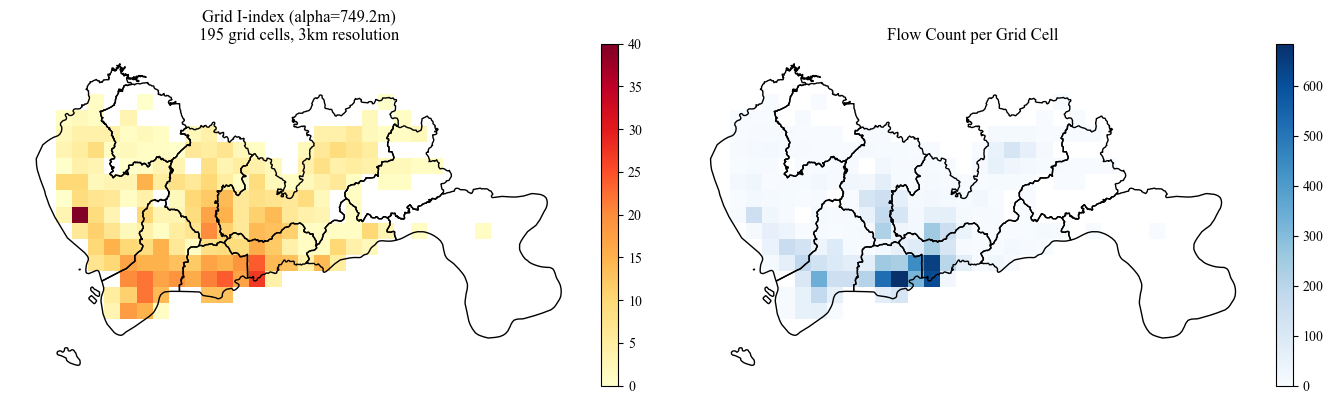

In [15]:
# Visualize grid-based I-index
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Grid I-index distribution
result_grid.plot(column='I_index', cmap='YlOrRd', legend=True, ax=axes[0],
                 legend_kwds={'shrink': 0.6, 'aspect': 20, 'pad': 0.02})
zones.plot(facecolor='none', ax=axes[0])
axes[0].set_title(f'Grid I-index (alpha={result_grid["alpha"].iloc[0]:.1f}m)\n{len(result_grid)} grid cells, '
                  f'{grid_size/1000:.0f}km resolution')
axes[0].set_axis_off()

# Plot 2: Flow count per grid cell
result_grid.plot(column='flow_count', cmap='Blues', legend=True, ax=axes[1],
                 legend_kwds={'shrink': 0.6, 'aspect': 20, 'pad': 0.02})
zones.plot(facecolor='none', ax=axes[1])
axes[1].set_title('Flow Count per Grid Cell')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [16]:
# Find top irreplaceable grid cells
top_grid_cells = result_grid.nlargest(10, 'I_index')[['zone_id', 'I_index', 'flow_count', 'total_length']]
print('Top 10 Irreplaceable Grid Cells:')
top_grid_cells

Top 10 Irreplaceable Grid Cells:


,zone_id,I_index,flow_count,total_length
8,8,40,149,3343.156629
120,120,27,612,3618.481710
102,102,24,684,3785.117207
121,121,24,642,3200.006070
49,49,22,175,1296.144460
50,50,22,340,2058.563462
91,91,21,520,3014.951353
38,38,20,100,754.946952
94,94,20,222,1750.674253
72,72,19,148,1178.263965
